### 1. Import necessary libraries

In [3]:
# This Source Code Form is subject to the terms of the
# CC BY-NC-SA 4.0 License. If a copy of the same was not
# distributed with this file, You can obtain one at
# https://github.com/akhilpandey95/tinker/blob/main/LICENSE.

# gen
import json
import os
import re
import matplotlib.pyplot as plt
import polars as pl
from dataclasses import dataclass

# sdk
import tinker
from tinker import types

# set API key
os.environ["TINKER_API_KEY"] = "tml-nf3bgE0r6GNsCpjoeHP28MXb9gqfdbYHUA6wFIzLIRRCgSXMlPJd3pKsairT0FO7FAAAA"

### 2. Setup config

In [4]:
# disruption labels
LABELS = ("disruptive", "consolidating", "neutral")
LLM = "Qwen/Qwen3-8B"

# structure for each paper item
@dataclass
class PaperRecord:
    title: str
    abstract: str
    year: int | None = None
    citations: int | None = None
    field: str | None = None
    gold_label: str | None = None

# structure of the base env
@dataclass(frozen=True)
class EnvConfig:
    model: str = LLM
    lora_rank: int = 32
    max_tokens: int = 192
    temperature: float = 0.0
    stop_seq: tuple[str, ...] = ("\n\n",)

# structure of the disruption env
class DisruptionEnv:
    # init
    def __init__(self, config: EnvConfig) -> None:
        self.config = config
        self.service_client = tinker.ServiceClient()
        self.training_client = None
        self.tokenizer = None

    # tinker client connection
    def connect(self):
        # is it not set ?
        if self.training_client is None:
            # set training client, tokenizer
            self.training_client = self.service_client.create_lora_training_client(base_model=self.config.model, rank=self.config.lora_rank)
            self.tokenizer = self.training_client.get_tokenizer()

        # return training client
        return self.training_client

    # helper function to build prompts
    def build_prompt(self, record: PaperRecord) -> str:
        record_lines = [
            f"Title: {record.title}",
            f"Abstract: {record.abstract}",
        ]

        for key, value in (
            ("Year", record.year),
            ("Citations", record.citations),
            ("Field", record.field),
        ):
            if value is not None:
                record_lines.append(f"{key}: {value}")

        prompt_lines = [
            "You are a careful scientific literature analyst.",
            "Classify the paper using only the record below.",
            "",
            "Task:",
            "Decide whether the paper is disruptive, consolidating, or neutral.",
            "",
            "Output requirements:",
            "Return one JSON object with exactly four keys.",
            "Keys: disruption_label, label_justification, evidence_signals, confidence.",
            "Allowed disruption_label values: disruptive, consolidating, neutral.",
            "label_justification must be 2-3 short grounded sentences.",
            "evidence_signals must be a JSON array of 2-4 short strings.",
            "confidence must be low, medium, or high.",
            "Use double-quoted JSON strings.",
            "Do not use markdown fences.",
            "Do not include <think> tags.",
            "",
            "Paper record:",
            *record_lines,
            "",
            "Continue the JSON object below.",
            "{",
        ]

        return "\n".join(prompt_lines)

    def encode_prompt(self, prompt: str) -> types.ModelInput:
        self.connect()
        return types.ModelInput.from_ints(tokens=self.tokenizer.encode(prompt, add_special_tokens=True))

    def create_sampling_client(self, *, name: str = "disruption-env"):
        return self.connect().save_weights_and_get_sampling_client(name=name)

    def sample_completion(self, sampling_client, record: PaperRecord, *, num_samples: int = 1):
        prompt = self.build_prompt(record)
        result = sampling_client.sample(
            prompt=self.encode_prompt(prompt),
            sampling_params=types.SamplingParams(
                max_tokens=self.config.max_tokens,
                temperature=self.config.temperature,
                stop=list(self.config.stop_seq),
            ),
            num_samples=num_samples,
        ).result()
        completions = ["{" + self.tokenizer.decode(seq.tokens) for seq in result.sequences]
        return prompt, completions, result

    def clean_completion(self, completion: str) -> str:
        text = completion.strip()
        text = text.replace("<|endoftext|>", "").strip()

        if text.startswith("```json"):
            text = text[len("```json"):].strip()
        elif text.startswith("```"):
            text = text[len("```"):].strip()

        if text.endswith("```"):
            text = text[:-len("```")].strip()

        start = text.find("{")
        end = text.rfind("}")
        if start != -1 and end != -1 and end >= start:
            text = text[start : end + 1]

        return text.strip()

    def parse_completion(self, completion: str) -> tuple[str, str | None]:
        text = self.clean_completion(completion)
        if not text:
            return "empty", None

        if "<think>" in text or "</think>" in text:
            return "contains_think", None

        if not text.startswith("{") or not text.endswith("}"):
            return "not_json_object", None

        try:
            payload = json.loads(text)
        except json.JSONDecodeError:
            return "invalid_json", None

        if not isinstance(payload, dict):
            return "not_json_object", None

        if set(payload) != {
            "disruption_label",
            "label_justification",
            "evidence_signals",
            "confidence",
        }:
            return "bad_keys", None

        label = payload.get("disruption_label")
        justification = payload.get("label_justification")
        evidence_signals = payload.get("evidence_signals")
        confidence = payload.get("confidence")

        if not isinstance(label, str) or label.lower() not in LABELS:
            return "bad_label", None

        if not isinstance(justification, str) or not justification.strip():
            return "bad_justification", None

        if not isinstance(evidence_signals, list) or not evidence_signals:
            return "bad_evidence_signals", None

        if not all(isinstance(item, str) and item.strip() for item in evidence_signals):
            return "bad_evidence_signals", None

        if confidence not in {"low", "medium", "high"}:
            return "bad_confidence", None

        return "ok", label.lower()

    def score_completion(self, record: PaperRecord, completion: str) -> tuple[float, str | None, str]:
        status, label = self.parse_completion(completion)
        if status != "ok":
            return -1.0, None, status

        if record.gold_label is None:
            return 0.0, label, status

        score = 1.0 if label == record.gold_label.lower() else -1.0
        return score, label, status

    def make_target(self, record: PaperRecord) -> str:
        if record.gold_label is None:
            raise ValueError("gold_label is required")

        label_targets = {
            "disruptive": {
                "label_justification": "The paper points toward a field-shifting direction. Its contribution goes beyond a routine extension of prior work.",
                "evidence_signals": ["new direction", "field-shifting potential"],
                "confidence": "medium",
            },
            "consolidating": {
                "label_justification": "The paper strengthens an existing line of work. Its contribution mainly reinforces established ideas and methods.",
                "evidence_signals": ["extends prior line", "reinforces existing methods"],
                "confidence": "medium",
            },
            "neutral": {
                "label_justification": "The paper adds evidence within an existing line of work. Its contribution does not clearly shift the field direction.",
                "evidence_signals": ["mechanistic focus", "limited field-shifting scope"],
                "confidence": "medium",
            },
        }

        payload = {
            "disruption_label": record.gold_label,
            **label_targets[record.gold_label.lower()],
        }
        return json.dumps(payload)

    def make_datum(self, record: PaperRecord) -> types.Datum:
        self.connect()

        prompt = self.build_prompt(record)
        target = self.make_target(record)[1:] + "\n\n"

        prompt_tokens = self.tokenizer.encode(
            prompt,
            add_special_tokens=True,
        )
        target_tokens = self.tokenizer.encode(
            target,
            add_special_tokens=False,
        )

        tokens = prompt_tokens + target_tokens
        weights = [0] * len(prompt_tokens) + [1] * len(target_tokens)

        return types.Datum(
            model_input=types.ModelInput.from_ints(tokens=tokens[:-1]),
            loss_fn_inputs={
                "target_tokens": tokens[1:],
                "weights": weights[1:],
            },
        )

### 3. Load one paper from the dataset

In [5]:
# load df
df = pl.read_ndjson("../data/sci_balanced_from2m_no_ovr.rl_balanced.jsonl")
row = df.tail(-1).to_dicts()[0]

# test the paper record
paper = PaperRecord(
    title=row["title"],
    abstract=row["abstract"],
    year=row.get("publication_year"),
    citations=row.get("cited_by_count"),
    field=row.get("primary_field"),
    gold_label=row.get("disruption_label"),
)

# build the env display prompt
env = DisruptionEnv(EnvConfig())
prompt = env.build_prompt(paper)
print(prompt)

You are a careful scientific literature analyst.
Classify the paper using only the record below.

Task:
Decide whether the paper is disruptive, consolidating, or neutral.

Output requirements:
Return one JSON object with exactly four keys.
Keys: disruption_label, label_justification, evidence_signals, confidence.
Allowed disruption_label values: disruptive, consolidating, neutral.
label_justification must be 2-3 short grounded sentences.
evidence_signals must be a JSON array of 2-4 short strings.
confidence must be low, medium, or high.
Use double-quoted JSON strings.
Do not use markdown fences.
Do not include <think> tags.

Paper record:
Title: The von Hippel-Lindau Gene Product Inhibits Renal Cell Apoptosis via Bcl-2-dependent Pathways
Abstract: Previous studies have reported a protective role for the von Hippel-Lindau (<i>VHL</i>) gene products against pro-apoptotic cellular stresses, but the mechanisms remain unclear. In this study, we examined the role of <i>VHL</i> in renal cells

In [6]:
# sample once
sampling_client = env.create_sampling_client(name="disruption-smoke")
prompt, completions, result = env.sample_completion(
    sampling_client,
    paper,
)
completion = completions[0]
score, label, status = env.score_completion(paper, completion)

print(completion)
print(score, label, status)

{ "disruption_label": "neutral", "label_justification": "The paper presents a study on the role of the VHL gene in preventing apoptosis in renal cells, focusing on mechanisms involving Bcl-2 pathways. It does not introduce new methodologies or challenge existing paradigms but rather provides detailed insights into a specific biological process.", "evidence_signals": [ "Examined role of VHL in renal cells under hypoxia", "Demonstrated VHL's protective effect via Bcl-2 pathways", "Used established cell lines and molecular techniques", "No mention of novel technologies or paradigm shifts" ], "confidence": "high" }
Okay, let's tackle this classification. The paper's title and abstract are about the VHL gene's role in inhibiting apoptosis through Bcl-2 pathways. The key here is to determine if it's disruptive, consolidating, or neutral.


1.0 neutral ok


In [ ]:
# overfit one example for a few steps
client = env.connect()
datum = env.make_datum(paper)
train_steps = 25
losses = []
clock_cycles = []

for _ in range(train_steps):
    fwdbwd_result = client.forward_backward([datum], "cross_entropy").result()
    client.optim_step(types.AdamParams(learning_rate=1e-4)).result()
    losses.append(fwdbwd_result.metrics["loss:sum"])
    clock_cycles.append(fwdbwd_result.metrics.get("clock_cycle:unique"))

losses[:3], losses[-3:]

In [ ]:
# sample again after the overfit loop
sampling_client = env.create_sampling_client(name="disruption-after-train")
prompt, completions, result = env.sample_completion(
    sampling_client,
    paper,
)
completion = completions[0]
score, label, status = env.score_completion(paper, completion)

print(completion)
print(score, label, status)

In [ ]:
# visualize training metrics
steps = range(1, train_steps + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(steps, losses, marker="o", linewidth=1.5)
axes[0].set_title("Loss Sum")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("loss:sum")

axes[1].plot(steps, clock_cycles, marker="o", linewidth=1.5, color="tab:orange")
axes[1].set_title("Clock Cycle")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("clock_cycle:unique")

plt.tight_layout()
plt.show()

In [7]:
# cookbook RL imports
from dataclasses import dataclass
from typing import Sequence

import chz
from tinker_cookbook import renderers
from tinker_cookbook.rl import train as cookbook_rl_train
from tinker_cookbook.rl.types import Env as CookbookEnv
from tinker_cookbook.rl.types import EnvGroupBuilder as CookbookEnvGroupBuilder
from tinker_cookbook.rl.types import RLDataset as CookbookRLDataset
from tinker_cookbook.rl.types import RLDatasetBuilder as CookbookRLDatasetBuilder
from tinker_cookbook.rl.types import StepResult as CookbookStepResult
from tinker_cookbook.tokenizer_utils import get_tokenizer

In [8]:
# define a minimal cookbook RL env for disruption
def load_rl_records(
    dataset_path: str,
    *,
    limit: int | None = None,
    seed: int = 0,
) -> list[PaperRecord]:
    kwargs = {}
    if limit is not None:
        kwargs["n_rows"] = limit

    df = pl.read_ndjson(dataset_path, **kwargs)
    if len(df) > 1:
        df = df.sample(fraction=1.0, shuffle=True, seed=seed)

    records = []
    for row in df.to_dicts():
        label = row.get("disruption_label")
        if label not in LABELS:
            continue

        records.append(
            PaperRecord(
                title=row["title"],
                abstract=row["abstract"],
                year=row.get("publication_year"),
                citations=row.get("cited_by_count"),
                field=row.get("primary_field"),
                gold_label=label,
            )
        )

    return records


class DisruptionJSONContract:
    @staticmethod
    def build_messages(record: PaperRecord) -> list[renderers.Message]:
        system_text = "\n".join(
            [
                "You are a careful scientific literature analyst.",
                "Classify the paper using only the user-provided record.",
                "Return one JSON object with exactly four keys.",
                "Keys: disruption_label, label_justification, evidence_signals, confidence.",
                "Allowed disruption_label values: disruptive, consolidating, neutral.",
                "Do not use markdown fences.",
                "Do not include <think> tags.",
            ]
        )

        user_lines = [
            "Paper record:",
            f"Title: {record.title}",
            f"Abstract: {record.abstract}",
        ]

        for key, value in (
            ("Year", record.year),
            ("Citations", record.citations),
            ("Field", record.field),
        ):
            if value is not None:
                user_lines.append(f"{key}: {value}")

        user_lines.extend(
            [
                "",
                "Return JSON only.",
                "{",
            ]
        )

        return [
            {"role": "system", "content": system_text},
            {"role": "user", "content": "\n".join(user_lines)},
        ]

    @staticmethod
    def clean_completion(completion: str) -> str:
        text = completion.strip().replace("<|endoftext|>", "").strip()
        text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()

        if text.startswith("```json"):
            text = text[len("```json") :].strip()
        elif text.startswith("```"):
            text = text[len("```") :].strip()

        if text.endswith("```"):
            text = text[: -len("```")].strip()

        start = text.find("{")
        end = text.rfind("}")
        if start != -1 and end != -1 and end >= start:
            text = text[start : end + 1]

        return text.strip()

    @staticmethod
    def normalize_confidence(confidence):
        if confidence in {"low", "medium", "high"}:
            return confidence, True

        if isinstance(confidence, (int, float)) and 0.0 <= float(confidence) <= 1.0:
            value = float(confidence)
            if value < 0.34:
                return "low", False
            if value < 0.67:
                return "medium", False
            return "high", False

        return None, False

    @staticmethod
    def parse_completion(completion: str) -> tuple[str, str | None]:
        text = DisruptionJSONContract.clean_completion(completion)
        if not text:
            return "empty", None

        if not text.startswith("{") or not text.endswith("}"):
            return "not_json_object", None

        try:
            payload = json.loads(text)
        except json.JSONDecodeError:
            return "invalid_json", None

        if not isinstance(payload, dict):
            return "not_json_object", None

        if set(payload) != {
            "disruption_label",
            "label_justification",
            "evidence_signals",
            "confidence",
        }:
            return "bad_keys", None

        label = payload.get("disruption_label")
        justification = payload.get("label_justification")
        evidence_signals = payload.get("evidence_signals")
        confidence = payload.get("confidence")

        if not isinstance(label, str) or label.lower() not in LABELS:
            return "bad_label", None

        if not isinstance(justification, str) or not justification.strip():
            return "bad_justification", None

        if not isinstance(evidence_signals, list) or not evidence_signals:
            return "bad_evidence_signals", None

        if not all(isinstance(item, str) and item.strip() for item in evidence_signals):
            return "bad_evidence_signals", None

        confidence, confidence_is_strict = DisruptionJSONContract.normalize_confidence(confidence)
        if confidence is None:
            return "bad_confidence", None

        status = "ok" if confidence_is_strict else "ok_relaxed_confidence"
        return status, label.lower()

    @staticmethod
    def score(record: PaperRecord, completion: str) -> tuple[float, str | None, str]:
        status, label = DisruptionJSONContract.parse_completion(completion)
        if not status.startswith("ok"):
            return -1.0, None, status

        if record.gold_label is None:
            return 0.0, label, status

        score = 1.0 if label == record.gold_label.lower() else -1.0
        return score, label, status


class DisruptionRLEnv(CookbookEnv):
    def __init__(self, record: PaperRecord, renderer: renderers.Renderer) -> None:
        self.record = record
        self.renderer = renderer
        self.messages = DisruptionJSONContract.build_messages(record)

    @property
    def stop_condition(self):
        return self.renderer.get_stop_sequences()

    def _observation(self):
        return self.renderer.build_generation_prompt(self.messages)

    async def initial_observation(self):
        return self._observation(), self.stop_condition

    async def step(self, action):
        action_message, _ = self.renderer.parse_response(action)
        content = renderers.get_text_content(action_message)
        reward, label, status = DisruptionJSONContract.score(self.record, content)
        had_think_tags = int("<think>" in content or "</think>" in content)

        label_match = int(
            label is not None
            and self.record.gold_label is not None
            and label == self.record.gold_label.lower()
        )

        return CookbookStepResult(
            reward=reward,
            episode_done=True,
            next_observation=self._observation(),
            next_stop_condition=self.stop_condition,
            metrics={
                "parse_ok": int(status.startswith("ok")),
                "format_strict_ok": int(status == "ok"),
                "label_match": label_match,
                "had_think_tags": had_think_tags,
                "reward_total": reward,
            },
            logs={
                "status": status,
                "gold_label": self.record.gold_label or "",
                "pred_label": label or "",
                "title": self.record.title[:120],
            },
        )


@dataclass(frozen=True)
class DisruptionEnvGroupBuilder(CookbookEnvGroupBuilder):
    record: PaperRecord
    renderer: renderers.Renderer
    num_envs: int

    async def make_envs(self) -> Sequence[CookbookEnv]:
        return [
            DisruptionRLEnv(record=self.record, renderer=self.renderer)
            for _ in range(self.num_envs)
        ]


@dataclass(frozen=True)
class DisruptionRLDataset(CookbookRLDataset):
    records: list[PaperRecord]
    renderer: renderers.Renderer
    batch_size: int
    group_size: int

    def get_batch(self, index: int) -> Sequence[CookbookEnvGroupBuilder]:
        start = index * self.batch_size
        stop = min(start + self.batch_size, len(self.records))
        return [
            DisruptionEnvGroupBuilder(
                record=record,
                renderer=self.renderer,
                num_envs=self.group_size,
            )
            for record in self.records[start:stop]
        ]

    def __len__(self) -> int:
        return (len(self.records) + self.batch_size - 1) // self.batch_size


@chz.chz
class DisruptionDatasetBuilder(CookbookRLDatasetBuilder):
    dataset_path: str
    batch_size: int
    group_size: int
    model_name_for_tokenizer: str
    renderer_name: str = "qwen3_disable_thinking"
    train_size: int = 32
    test_size: int = 8
    seed: int = 0

    async def __call__(self) -> tuple[CookbookRLDataset, CookbookRLDataset]:
        tokenizer = get_tokenizer(self.model_name_for_tokenizer)
        renderer = renderers.get_renderer(self.renderer_name, tokenizer=tokenizer)
        total_rows = self.train_size + self.test_size
        records = load_rl_records(self.dataset_path, limit=total_rows, seed=self.seed)

        if len(records) < total_rows:
            raise ValueError(
                f"Need at least {total_rows} labeled records, found {len(records)}"
            )

        train_records = records[: self.train_size]
        test_records = records[self.train_size : total_rows]
        test_batch_size = max(1, min(self.batch_size, len(test_records)))

        train_ds = DisruptionRLDataset(
            records=train_records,
            renderer=renderer,
            batch_size=self.batch_size,
            group_size=self.group_size,
        )
        test_ds = DisruptionRLDataset(
            records=test_records,
            renderer=renderer,
            batch_size=test_batch_size,
            group_size=1,
        )
        return train_ds, test_ds


In [9]:
# build a small RL smoke-test config
RL_DATASET_PATH = "../data/sci_balanced_from2m_no_ovr.rl_balanced.jsonl"
RL_LOG_PATH = "/tmp/tinker-disruption-rl-smoke"


def build_disruption_rl_config(
    *,
    train_size: int = 32,
    test_size: int = 8,
    batch_size: int = 4,
    group_size: int = 4,
    learning_rate: float = 8e-6,
):
    builder = DisruptionDatasetBuilder(
        dataset_path=RL_DATASET_PATH,
        batch_size=batch_size,
        group_size=group_size,
        model_name_for_tokenizer=LLM,
        train_size=train_size,
        test_size=test_size,
    )

    return cookbook_rl_train.Config(
        learning_rate=learning_rate,
        dataset_builder=builder,
        model_name=LLM,
        max_tokens=192,
        log_path=RL_LOG_PATH,
        eval_every=5,
        save_every=25,
        loss_fn="importance_sampling",
        num_substeps=1,
        lora_rank=32,
        temperature=1.0,
    )


rl_config = build_disruption_rl_config()
train_rl_ds, test_rl_ds = await rl_config.dataset_builder()
first_group = train_rl_ds.get_batch(0)[0]
first_env = (await first_group.make_envs())[0]

{
    "train_batches": len(train_rl_ds),
    "test_batches": len(test_rl_ds),
    "group_size": train_rl_ds.group_size,
    "gold_label": first_env.record.gold_label,
    "stop_condition": first_env.stop_condition,
    "prompt_preview": first_env.messages[-1]["content"][:300],
}


{'train_batches': 8,
 'test_batches': 2,
 'group_size': 4,
 'gold_label': 'consolidating',
 'stop_condition': [151645],
 'prompt_preview': 'Paper record:\nTitle: Generalized group characters and complex oriented cohomology theories\nAbstract: Let $BG$ be the classifying space of a finite group $G$. Given a multiplicative cohomology theory $E^{*}$, the assignment \\[ G \\longmapsto E^{*}(BG) \\] is a functor from groups to rings, endowed with'}

tinker_cookbook.utils.ml_log:477 [INFO] Logging to: /tmp/tinker-disruption-rl-smoke
tinker_cookbook.checkpoint_utils:200 [INFO] Reading checkpoints from /tmp/tinker-disruption-rl-smoke/checkpoints.jsonl
tinker_cookbook.checkpoint_utils:222 [INFO] Found 1 valid checkpoints with key 'state_path' in /tmp/tinker-disruption-rl-smoke
tinker_cookbook.checkpoint_utils:225 [INFO] Using last checkpoint: {'name': 'final', 'batch': 2, 'state_path': 'tinker://109af6ec-8df9-5f59-a151-e50569bdea8c:train:0/weights/final', 'sampler_path': 'tinker://109af6ec-8df9-5f59-a151-e50569bdea8c:train:0/sampler_weights/final'}
tinker.lib.public_interfaces.service_client:67 [INFO] ServiceClient initialized for session a53488c5-2319-5e6b-919c-e4f657716501
tinker.lib.public_interfaces.service_client:151 [INFO] TrainingClient initialized for model a53488c5-2319-5e6b-919c-e4f657716501:train:0
tinker_cookbook.rl.train:1332 [INFO] Resumed training from tinker://109af6ec-8df9-5f59-a151-e50569bdea8c:train:0/weights/final


tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 2                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn     │ 131.687500 │
│ env/all/by_group/frac_all_bad  │ 0.500000   │
│ env/all/by_group/frac_all_good │ 0.250000   │
│ env/all/by_group/frac_mixed    │ 0.250000   │
│ env/all/format_strict_ok       │ 0.125000   │
│ env/all/had_think_tags         │ 0.000000   │
│ env/all/label_match            │ 0.437500   │
│ env/all/ob_tokens_per_turn     │ 392.250000 │
│ env/all/parse_ok               │ 1.000000   │
│ env/all/reward/total           │ -0.125000  │
│ env/all/reward_total           │ -0.125000  │
│ env/all/total_ac_tokens        │ 2107       │
│ env/all/total_episodes         │ 16         │
│ env/all/total_ob_tokens        │ 6276       │
│ env/all/total_turns            │ 16         │
│ env/all/turns_per_episode      │ 1.000000   │

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 3                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn     │ 120.500000 │
│ env/all/by_group/frac_all_bad  │ 1.000000   │
│ env/all/by_group/frac_all_good │ 0.000000   │
│ env/all/by_group/frac_mixed    │ 0.000000   │
│ env/all/format_strict_ok       │ 0.500000   │
│ env/all/had_think_tags         │ 0.000000   │
│ env/all/label_match            │ 0.000000   │
│ env/all/ob_tokens_per_turn     │ 377.500000 │
│ env/all/parse_ok               │ 1.000000   │
│ env/all/reward/total           │ -1.000000  │
│ env/all/reward_total           │ -1.000000  │
│ env/all/total_ac_tokens        │ 1928       │
│ env/all/total_episodes         │ 16         │
│ env/all/total_ob_tokens        │ 6040       │
│ env/all/total_turns            │ 16         │
│ env/all/turns_per_episode      │ 1.000000   │

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 4                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn     │ 123.187500 │
│ env/all/by_group/frac_all_bad  │ 0.750000   │
│ env/all/by_group/frac_all_good │ 0.000000   │
│ env/all/by_group/frac_mixed    │ 0.250000   │
│ env/all/format_strict_ok       │ 0.187500   │
│ env/all/had_think_tags         │ 0.000000   │
│ env/all/label_match            │ 0.125000   │
│ env/all/ob_tokens_per_turn     │ 423.250000 │
│ env/all/parse_ok               │ 0.937500   │
│ env/all/reward/total           │ -0.750000  │
│ env/all/reward_total           │ -0.750000  │
│ env/all/total_ac_tokens        │ 1971       │
│ env/all/total_episodes         │ 16         │
│ env/all/total_ob_tokens        │ 6772       │
│ env/all/total_turns            │ 16         │
│ env/all/turns_per_episode      │ 1.000000   │

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 5                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn     │ 109.250000 │
│ env/all/by_group/frac_all_bad  │ 0.750000   │
│ env/all/by_group/frac_all_good │ 0.250000   │
│ env/all/by_group/frac_mixed    │ 0.000000   │
│ env/all/format_strict_ok       │ 0.375000   │
│ env/all/had_think_tags         │ 0.000000   │
│ env/all/label_match            │ 0.250000   │
│ env/all/ob_tokens_per_turn     │ 304.500000 │
│ env/all/parse_ok               │ 1.000000   │
│ env/all/reward/total           │ -0.500000  │
│ env/all/reward_total           │ -0.500000  │
│ env/all/total_ac_tokens        │ 1748       │
│ env/all/total_episodes         │ 16         │
│ env/all/total_ob_tokens        │ 4872       │
│ env/all/total_turns            │ 16         │
│ env/all/turns_per_episode      │ 1.000000   │

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 6                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn     │ 117.687500 │
│ env/all/by_group/frac_all_bad  │ 0.500000   │
│ env/all/by_group/frac_all_good │ 0.000000   │
│ env/all/by_group/frac_mixed    │ 0.500000   │
│ env/all/format_strict_ok       │ 0.375000   │
│ env/all/had_think_tags         │ 0.000000   │
│ env/all/label_match            │ 0.312500   │
│ env/all/ob_tokens_per_turn     │ 379.500000 │
│ env/all/parse_ok               │ 1.000000   │
│ env/all/reward/total           │ -0.375000  │
│ env/all/reward_total           │ -0.375000  │
│ env/all/total_ac_tokens        │ 1883       │
│ env/all/total_episodes         │ 16         │
│ env/all/total_ob_tokens        │ 6072       │
│ env/all/total_turns            │ 16         │
│ env/all/turns_per_episode      │ 1.000000   │

tinker_cookbook.utils.ml_log:197 [INFO] 
                    Step 7                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Metric                         ┃ Value      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ env/all/ac_tokens_per_turn     │ 130.812500 │
│ env/all/by_group/frac_all_bad  │ 0.500000   │
│ env/all/by_group/frac_all_good │ 0.250000   │
│ env/all/by_group/frac_mixed    │ 0.250000   │
│ env/all/format_strict_ok       │ 0.062500   │
│ env/all/had_think_tags         │ 0.000000   │
│ env/all/label_match            │ 0.437500   │
│ env/all/ob_tokens_per_turn     │ 397.750000 │
│ env/all/parse_ok               │ 1.000000   │
│ env/all/reward/total           │ -0.125000  │
│ env/all/reward_total           │ -0.125000  │
│ env/all/total_ac_tokens        │ 2093       │
│ env/all/total_episodes         │ 16         │
│ env/all/total_ob_tokens        │ 6364       │
│ env/all/total_turns            │ 16         │
│ env/all/turns_per_episode      │ 1.000000   │

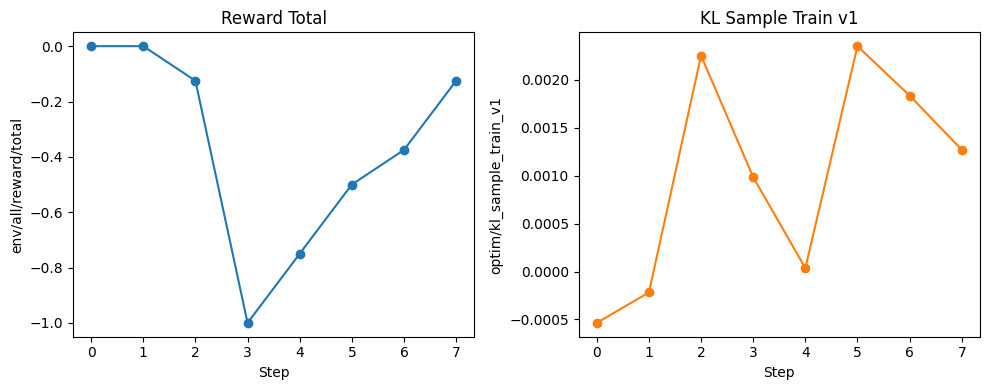

In [11]:
# helpers for the actual RL run
async def run_disruption_rl(cfg=None):
    cfg = cfg or build_disruption_rl_config()
    await cookbook_rl_train.main(cfg)


def plot_rl_metrics(metrics_path: str = f"{RL_LOG_PATH}/metrics.jsonl"):
    df = pl.read_ndjson(metrics_path)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    reward_candidates = ["env/all/reward/total", "env/all/reward_total"]
    kl_candidates = ["optim/kl_sample_train_v1", "kl_sample_train_v1"]
    reward_col = next((col for col in reward_candidates if col in df.columns), None)
    kl_col = next((col for col in kl_candidates if col in df.columns), None)

    if reward_col is not None:
        axes[0].plot(df[reward_col].to_list(), marker="o", linewidth=1.5)
        axes[0].set_title("Reward Total")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel(reward_col)
    else:
        axes[0].set_title("Reward Total")
        axes[0].text(0.5, 0.5, "missing metric", ha="center", va="center")

    if kl_col is not None:
        axes[1].plot(
            df[kl_col].to_list(),
            marker="o",
            linewidth=1.5,
            color="tab:orange",
        )
        axes[1].set_title("KL Sample Train v1")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel(kl_col)
    else:
        axes[1].set_title("KL Sample Train v1")
        axes[1].text(0.5, 0.5, "missing metric", ha="center", va="center")

    plt.tight_layout()
    plt.show()


await run_disruption_rl()
plot_rl_metrics()